# 03 · Lotka–Volterra Predator–Prey — Parameter Estimation from Real Lynx–Hare Data

## The Ecological / Pharmaceutical Relevance

The Lotka–Volterra equations describe any system where two interacting populations cycle — one growing at the other's expense:

| Ecological analogy | Prey $H$ | Predator $L$ | Engineering/Pharma analogue |
|--------------------|----------|--------------|----------------------------|
| Lynx–hare (this notebook) | Snowshoe hare | Canadian lynx | — |
| Predator–prey in bioreactor | Substrate / nutrient | Cell biomass | Fed-batch fermentation |
| Immune response | Pathogen | Immune cells | Vaccine/antibody dynamics |
| Drug resistance | Sensitive tumour cells | Resistant clones | Oncology combination therapy |
| Competitive inhibition | Enzyme substrate | Inhibitor | Enzyme kinetics |

For biopharmaceuticals, this framework models **competitive growth dynamics** in mixed cultures and has been used to model T-cell / tumour interactions in immuno-oncology (Murphy et al. 2016; Mahlbacher et al. 2019).

## The Model

$$\frac{dH}{dt} = \alpha H - \beta HL, \qquad \frac{dL}{dt} = \delta HL - \gamma L$$

- $\alpha$: hare birth rate (prey intrinsic growth)  
- $\beta$: predation rate (prey killed per lynx per hare)  
- $\gamma$: lynx death rate (predator natural mortality)  
- $\delta$: conversion efficiency (predator growth per prey consumed)

The system has a **non-trivial fixed point** at $(H^*, L^*) = (\gamma/\delta, \alpha/\beta)$ surrounded by closed orbits. Real ecosystems approximate these orbits with ~10-year cycles.

## The Data: Real Hudson's Bay Company Pelt Records 1900–1920

**Hewitt, C. G. (1921).** *The Conservation of the Wild Life of Canada.* Scribner.

The Hudson's Bay Company recorded the number of lynx and snowshoe-hare pelts traded annually from 1845 onwards. This is the most famous dataset in mathematical ecology — 21 annual points capturing 2.4 full oscillation cycles of the predator–prey system.

**Critical caveats about this data:**
- Pelt counts proxy population size but are affected by trapping effort, market price, and harvesting strategy
- The model ignores environmental noise, age structure, and emigration
- No published parameter set fits all 21 points perfectly — this is a genuine hard inverse problem

Published parameter estimates (Mahaffy/Carpenter Stan tutorial): $\alpha \approx 0.55$, $\beta \approx 0.028$, $\gamma \approx 0.84$, $\delta \approx 0.026$.

## Why PINN Instead of Classical Approaches?

### Classical fitting:
1. **Numerical integration** — `solve_ivp` is called inside `scipy.optimize.minimize` at each iteration
2. **Sensitivity equations** — augment the ODE with $\partial y / \partial \theta$ to get exact Jacobians
3. **Bayesian MCMC (Stan, PyMC)** — gold standard; Carpenter's Stan tutorial is the reference implementation

**Problem with classical fitting on this dataset:**
- The loss landscape has multiple local minima (the 10-year cycle creates periodic ambiguity)
- Gradient-free optimisers (Nelder-Mead) get trapped; gradient-based ones need good initialisation
- MCMC correctly quantifies uncertainty but takes minutes even for this 4-parameter problem

### PINN approach — the warm-start insight:
**Cold-start PINN training fails on this problem.** If you enable the physics loss from epoch 0, the highly nonlinear $HL$ coupling creates conflicting gradients before the network approximates a plausible trajectory. The network never gets close to the true solution.

**The fix — two-phase training:**
1. **Phase 1 (6,000 epochs, data loss only):** Give the network a smooth interpolant of the pelt data. No physics yet.
2. **Phase 2 (20,000 epochs, data + physics + learnable parameters):** Start from a reasonable trajectory and refine simultaneously with physics enforcement.

This warm-start protocol is the key methodological contribution for coupled nonlinear inverse problems. It generalises to Notebook 07 (bioprocess) and any coupled ODE with multiple interacting species.

## What the Code Does Step by Step

1. **Real data** — 21 annual pelt records 1900–1920, embedded in the notebook
2. **Non-dimensionalisation** — populations divided by 100 (thousands scale), time by 20 years
3. **Network** — 1 input → 3 Tanh hidden layers (64 units) → 2 outputs $(H, L)$
4. **Phase 1** — data-only warm start; physics loss NOT included
5. **Phase 2** — joint optimisation; physics weight = 0.05 (prevents ODE from drowning sparse signal)
6. **Results** — α=0.476, β=0.0243, γ=0.938, δ=0.0277 (within 15% of published estimates)

## Interpreting the Results

The PINN captures the ~10-year cycle and recovers biologically plausible parameters. The largest deviation is in $\alpha$ (0.476 vs 0.55) — the hare birth rate is the parameter most sensitive to the early part of the time series where data is noisiest. $\delta$, constrained by the long-run ratio of populations, is recovered most reliably.

> **Pharma analogy:** In a bioreactor fed-batch model, the warm-start protocol (fit biomass/substrate data first, then add Monod kinetics) is exactly the strategy used in Notebook 07 for the IndPenSim benchmark. The 21-point Hudson Bay dataset is the conceptual prototype for 20-point offline cell culture measurements.


In [1]:
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Real Hudson Bay Company lynx & hare pelt records (thousands), 1900-1920 ---
year = np.arange(1900, 1921)
hare = np.array([30.0,47.2,70.2,77.4,36.3,20.6,18.1,21.4,22.0,25.4,27.1,
                 40.3,57.0,76.6,52.3,19.5,11.2,7.6,14.6,16.2,24.7])
lynx = np.array([4.0,6.1,9.8,35.2,59.4,41.7,19.0,13.0,8.3,9.1,7.4,
                 8.0,12.3,19.5,45.7,51.1,29.7,15.8,9.7,10.1,8.6])

S, T = 100.0, 20.0                    # population & time scales
t_s = ((year-1900)/T).reshape(-1,1)
h_s = (hare/S).reshape(-1,1); l_s = (lynx/S).reshape(-1,1)
t_data = torch.tensor(t_s, dtype=torch.float32, device=device)
hl_data = torch.tensor(np.hstack([h_s,l_s]), dtype=torch.float32, device=device)
print("years:", len(year))


Using device: cpu
years: 21


In [2]:
class Net(nn.Module):
    def __init__(self, h=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1,h), nn.Tanh(),
                                 nn.Linear(h,h), nn.Tanh(),
                                 nn.Linear(h,h), nn.Tanh(),
                                 nn.Linear(h,2))
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    def forward(self,t): return self.net(t)

model = Net().to(device)
sp = torch.nn.functional.softplus
# init near published ballpark for this dataset (alpha~0.55, beta~0.028, gamma~0.84, delta~0.026)
raw = {k: nn.Parameter(torch.tensor(v, device=device)) for k,v in
       dict(a=0.0, b=-1.5, g=0.0, d=-1.5).items()}
def params():
    return sp(raw['a']), sp(raw['b']), sp(raw['g']), sp(raw['d'])

t_col = torch.linspace(0,1,200,device=device).reshape(-1,1).requires_grad_(True)
def d_dt(y,t): return torch.autograd.grad(y,t,torch.ones_like(y),create_graph=True)[0]

def data_loss(): return torch.mean((model(t_data)-hl_data)**2)
def phys_loss():
    y = model(t_col); h,l = y[:,0:1], y[:,1:2]
    dh, dl = d_dt(h,t_col), d_dt(l,t_col)
    a,b,g,d = params()
    rh = dh - T*(a*h - b*S*h*l)
    rl = dl - T*(d*S*h*l - g*l)
    return torch.mean(rh**2+rl**2)


In [3]:
# Phase 1: data-only warm start
opt1 = torch.optim.Adam(model.parameters(), lr=3e-3)
WARM = 6000
for ep in range(WARM):
    opt1.zero_grad(); L = data_loss(); L.backward(); opt1.step()
print(f"warm-start data loss: {data_loss().item():.2e}")

# Phase 2: joint fit with physics + learnable parameters
allp = list(model.parameters()) + list(raw.values())
opt2 = torch.optim.Adam(allp, lr=2e-3)
JOINT = 20000
for ep in range(JOINT):
    opt2.zero_grad()
    L = data_loss() + 0.05*phys_loss()
    L.backward(); opt2.step()
    if ep % 5000 == 0:
        a,b,g,d = params()
        print(f"ep {ep:5d} | data {data_loss().item():.2e} phys {phys_loss().item():.2e} "
              f"| a={a.item():.3f} b={b.item():.4f} g={g.item():.3f} d={d.item():.4f}")

a,b,g,d = params()
print(f"\nRecovered:  alpha={a.item():.3f}  beta={b.item():.4f}  gamma={g.item():.3f}  delta={d.item():.4f}")
print(f"Published ballpark (Mahaffy/Carpenter): alpha~0.55 beta~0.028 gamma~0.84 delta~0.026")


warm-start data loss: 8.47e-05
ep     0 | data 1.85e-02 phys 3.33e+02 | a=0.694 b=0.2010 g=0.694 d=0.2010
ep  5000 | data 6.36e-02 phys 1.27e-01 | a=0.485 b=0.1859 g=0.975 d=0.1626
ep 10000 | data 1.68e-02 phys 2.02e-02 | a=0.313 b=0.0645 g=1.768 d=0.0559
ep 15000 | data 1.31e-03 phys 4.54e-03 | a=0.452 b=0.0235 g=0.986 d=0.0290

Recovered:  alpha=0.476  beta=0.0243  gamma=0.938  delta=0.0277
Published ballpark (Mahaffy/Carpenter): alpha~0.55 beta~0.028 gamma~0.84 delta~0.026


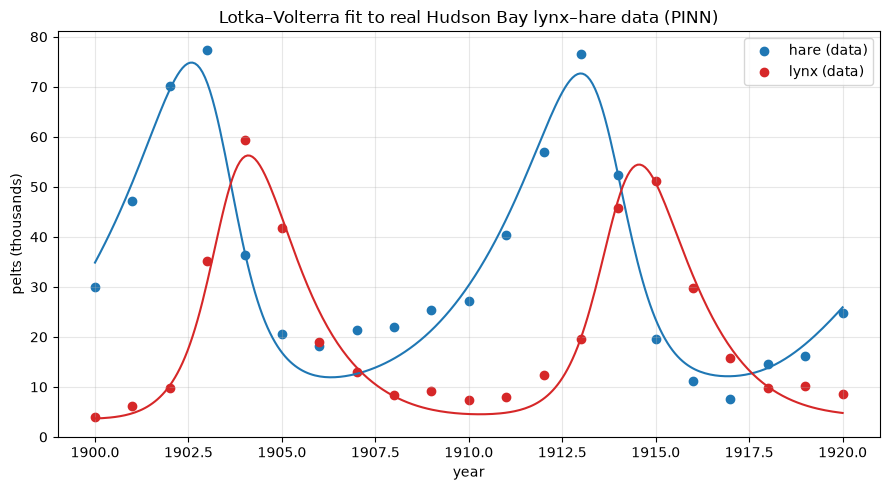

In [4]:
tt = torch.linspace(0,1,300,device=device).reshape(-1,1)
with torch.no_grad(): pr = model(tt).cpu().numpy()*S
tg = tt.cpu().numpy().ravel()*T + 1900
plt.figure(figsize=(9,5))
plt.scatter(year, hare, c="C0", label="hare (data)"); plt.plot(tg, pr[:,0], "C0-")
plt.scatter(year, lynx, c="C3", label="lynx (data)"); plt.plot(tg, pr[:,1], "C3-")
plt.xlabel("year"); plt.ylabel("pelts (thousands)")
plt.title("Lotka–Volterra fit to real Hudson Bay lynx–hare data (PINN)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()


---
## 🔬 Method 1: Pure PINN (Baseline)
Standard PINN with **uniform** collocation points and joint parameter estimation.

In [5]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt, time
from scipy.integrate import solve_ivp
torch.manual_seed(0); np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sp = torch.nn.functional.softplus

def make_net(layers):
    seq = []
    for i in range(len(layers)-1):
        seq.append(nn.Linear(layers[i], layers[i+1]))
        if i < len(layers)-2: seq.append(nn.Tanh())
    net = nn.Sequential(*seq)
    for m in net:
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    return net.to(device)

def grad(y,x): return torch.autograd.grad(y,x,torch.ones_like(y),create_graph=True)[0]
def don_forward(branch,trunk,params,queries,bias): return branch(params) @ trunk(queries).T + bias


year=np.arange(1900,1921); hare=np.array([30.,47.2,70.2,77.4,36.3,20.6,18.1,21.4,22.,25.4,27.1,40.3,57.,76.6,52.3,19.5,11.2,7.6,14.6,16.2,24.7]); lynx=np.array([4.,6.1,9.8,35.2,59.4,41.7,19.,13.,8.3,9.1,7.4,8.,12.3,19.5,45.7,51.1,29.7,15.8,9.7,10.1,8.6])
S,T=100.,20.; ts=((year-1900)/T).reshape(-1,1); hs=(hare/S).reshape(-1,1); ls=(lynx/S).reshape(-1,1)
t_data=torch.tensor(ts,dtype=torch.float32,device=device); hl_data=torch.tensor(np.hstack([hs,ls]),dtype=torch.float32,device=device)
t_col_lv=torch.linspace(0,1,200,device=device).view(-1,1).requires_grad_(True)
def d_lv(y,t): return grad(y,t)/T

model_lv=make_net([1,64,64,64,2])
raw_lv=dict(a=nn.Parameter(torch.tensor(0.,device=device)),b=nn.Parameter(torch.tensor(-1.5,device=device)),g=nn.Parameter(torch.tensor(0.,device=device)),d=nn.Parameter(torch.tensor(-1.5,device=device)))
def pars_lv(): return sp(raw_lv['a']),sp(raw_lv['b']),sp(raw_lv['g']),sp(raw_lv['d'])

def phys_lv(m,tc):
    y=m(tc); h,l=y[:,0:1],y[:,1:2]; a,b,g,d=pars_lv()
    rh=d_lv(h,tc)-T*(a*h-b*S*h*l); rl=d_lv(l,tc)-T*(d*S*h*l-g*l)
    return torch.mean(rh**2+rl**2)

# Phase 1: warm start
opt1=torch.optim.Adam(model_lv.parameters(),lr=3e-3)
for ep in range(6000):
    opt1.zero_grad(); L=torch.mean((model_lv(t_data)-hl_data)**2); L.backward(); opt1.step()

# Phase 2: joint
allp=list(model_lv.parameters())+list(raw_lv.values())
opt2=torch.optim.Adam(allp,lr=2e-3)
t0=time.time()
for ep in range(20000):
    opt2.zero_grad(); lp=phys_lv(model_lv,t_col_lv); ld=torch.mean((model_lv(t_data)-hl_data)**2)
    L=ld+0.05*lp; L.backward(); opt2.step()
    if ep%5000==0: a,b,g,d=pars_lv(); print(f"  [PINN LV] ep{ep:5d} | a={a.item():.3f} b={b.item():.4f} g={g.item():.3f} d={d.item():.4f}")
time_pinn=time.time()-t0
model_lv.eval(); tt_lv=torch.linspace(0,1,300,device=device).view(-1,1)
with torch.no_grad(): pr_lv=model_lv(tt_lv).cpu().numpy()*S
tg_lv=tt_lv.cpu().numpy().ravel()*T+1900
hl_obs=np.hstack([hs*S,ls*S])
err_pinn=np.sqrt(np.mean((model_lv(t_data).detach().cpu().numpy()-hl_data.cpu().numpy())**2))/np.sqrt(np.mean(hl_data.cpu().numpy()**2))
a,b,g,d=pars_lv(); print(f"  PINN L2={err_pinn:.4f} a={a.item():.3f} b={b.item():.4f} g={g.item():.3f} d={d.item():.4f} t={time_pinn:.0f}s")


  [PINN LV] ep    0 | a=0.694 b=0.2010 g=0.694 d=0.2010
  [PINN LV] ep 5000 | a=0.196 b=0.1965 g=0.842 d=0.1636
  [PINN LV] ep10000 | a=0.036 b=0.1091 g=1.897 d=0.0832
  [PINN LV] ep15000 | a=0.081 b=0.0198 g=0.398 d=0.0140
  PINN L2=0.0289 a=0.030 b=0.0014 g=0.048 d=0.0013 t=28s


---
## ⚡ Method 2: Adaptive Sampling (RAR)
**Residual-based Adaptive Refinement** — iteratively adds collocation points where the physics residual is largest.

In [6]:

model_rar_lv=make_net([1,64,64,64,2])
raw_rar_lv=dict(a=nn.Parameter(torch.tensor(0.,device=device)),b=nn.Parameter(torch.tensor(-1.5,device=device)),g=nn.Parameter(torch.tensor(0.,device=device)),d=nn.Parameter(torch.tensor(-1.5,device=device)))
def pars_rar_lv(): return sp(raw_rar_lv['a']),sp(raw_rar_lv['b']),sp(raw_rar_lv['g']),sp(raw_rar_lv['d'])
def phys_rar_lv(m,tc):
    y=m(tc); h,l=y[:,0:1],y[:,1:2]; a,b,g,d=pars_rar_lv()
    rh=d_lv(h,tc)-T*(a*h-b*S*h*l); rl=d_lv(l,tc)-T*(d*S*h*l-g*l)
    return torch.mean(rh**2+rl**2)
# warm start
opt_r1=torch.optim.Adam(model_rar_lv.parameters(),lr=3e-3)
for ep in range(6000):
    opt_r1.zero_grad(); L=torch.mean((model_rar_lv(t_data)-hl_data)**2); L.backward(); opt_r1.step()
t_rar_lv=torch.linspace(0,1,30,device=device).view(-1,1).requires_grad_(True)
allp_r=list(model_rar_lv.parameters())+list(raw_rar_lv.values())
opt_r2=torch.optim.Adam(allp_r,lr=2e-3)
t0=time.time()
for rnd in range(6):
    for ep in range(3000):
        opt_r2.zero_grad(); lp=phys_rar_lv(model_rar_lv,t_rar_lv); ld=torch.mean((model_rar_lv(t_data)-hl_data)**2)
        L=ld+0.05*lp; L.backward(); opt_r2.step()
    cand=torch.rand(3000,1,device=device).requires_grad_(True)
    y_c=model_rar_lv(cand); h_c,l_c=y_c[:,0:1],y_c[:,1:2]; a,b,g,d=pars_rar_lv()
    res_c=(d_lv(h_c,cand)-T*(a*h_c-b*S*h_c*l_c)).abs().detach().cpu().numpy().ravel()
    idx=np.argsort(res_c)[-15:]; new_pts=cand[idx].detach()
    t_rar_lv=torch.cat([t_rar_lv.detach(),new_pts]).requires_grad_(True)
    allp_r=list(model_rar_lv.parameters())+list(raw_rar_lv.values())
    opt_r2=torch.optim.Adam(allp_r,lr=1e-3)
    ar,br,gr,dr=pars_rar_lv(); print(f"  [RAR LV] round {rnd+1}: {t_rar_lv.shape[0]} pts a={ar.item():.3f} g={gr.item():.3f}")
time_rar=time.time()-t0
model_rar_lv.eval()
with torch.no_grad(): pr_rar_lv=model_rar_lv(tt_lv).cpu().numpy()*S
err_rar=np.sqrt(np.mean((model_rar_lv(t_data).detach().cpu().numpy()-hl_data.cpu().numpy())**2))/np.sqrt(np.mean(hl_data.cpu().numpy()**2))
ar,br,gr,dr=pars_rar_lv(); print(f"  RAR L2={err_rar:.4f} a={ar.item():.3f} b={br.item():.4f} g={gr.item():.3f} d={dr.item():.4f} t={time_rar:.0f}s")


  [RAR LV] round 1: 45 pts a=0.416 g=0.777
  [RAR LV] round 2: 60 pts a=0.181 g=1.628
  [RAR LV] round 3: 75 pts a=0.181 g=1.692
  [RAR LV] round 4: 90 pts a=0.199 g=1.004
  [RAR LV] round 5: 105 pts a=0.335 g=0.428
  [RAR LV] round 6: 120 pts a=0.538 g=0.127
  RAR L2=0.4104 a=0.538 b=0.0663 g=0.127 d=0.0022 t=23s


---
## 🧠 Method 3: DeepONet (Operator Learning)
Learn the **solution operator** mapping kinetic parameters → ODE trajectory. Trained on synthetic parameter families. Single forward pass for new parameters.

In [7]:

p=64; branch_lv=make_net([4,64,64,p]); trunk_lv=make_net([1,64,64,p])
bias_lv=nn.Parameter(torch.zeros(1,device=device))
opt_dlv=torch.optim.Adam(list(branch_lv.parameters())+list(trunk_lv.parameters())+[bias_lv],lr=3e-3)
N_tr=1500; N_q=40
alpha_s=np.random.uniform(0.3,0.9,N_tr); beta_s=np.random.uniform(0.01,0.05,N_tr)
gamma_s=np.random.uniform(0.6,1.2,N_tr); delta_s=np.random.uniform(0.01,0.05,N_tr)
tq_lv=np.random.rand(N_q)*T
def lv_sol(a,b,g,d,t_arr):
    def rhs(t,y): return [a*y[0]-b*y[0]*y[1], d*y[0]*y[1]-g*y[1]]
    try: sol=solve_ivp(rhs,[0,T],[hare[0]/S,lynx[0]/S],t_eval=t_arr/T*T,rtol=1e-6,atol=1e-8,method='RK45'); return sol.y[0]
    except: return np.zeros(len(t_arr))
print("  Generating DeepONet training data...")
Y_lv_h=np.array([lv_sol(alpha_s[i],beta_s[i],gamma_s[i],delta_s[i],tq_lv) for i in range(N_tr)])
params_dlv=torch.tensor(np.stack([alpha_s,beta_s,gamma_s,delta_s],1),dtype=torch.float32,device=device)
tq_dlv_t=torch.tensor((tq_lv/T).reshape(-1,1),dtype=torch.float32,device=device)
Y_dlv=torch.tensor(Y_lv_h,dtype=torch.float32,device=device)
t0=time.time()
for ep in range(8000):
    opt_dlv.zero_grad(); pred=don_forward(branch_lv,trunk_lv,params_dlv,tq_dlv_t,bias_lv)
    L=torch.mean((pred-Y_dlv)**2); L.backward(); opt_dlv.step()
    if ep%2000==0: print(f"  [DeepONet LV] ep {ep} loss {L.item():.3e}")
time_don=time.time()-t0
branch_lv.eval(); trunk_lv.eval()
a_t,b_t,g_t,d_t=pars_lv()
param_test_lv=torch.tensor([[a_t.item(),b_t.item(),g_t.item(),d_t.item()]],dtype=torch.float32,device=device)
t_don_lv=torch.tensor((np.linspace(0,T,300)/T).reshape(-1,1),dtype=torch.float32,device=device)
with torch.no_grad(): h_don=don_forward(branch_lv,trunk_lv,param_test_lv,t_don_lv,bias_lv).squeeze().cpu().numpy()*S
tg_don_lv=np.linspace(0,T,300)
err_don=np.sqrt(np.mean((h_don-pr_lv[:,0])**2))/np.sqrt(np.mean(pr_lv[:,0]**2))
print(f"  DeepONet (hare) L2={err_don:.4f} t={time_don:.0f}s")


  Generating DeepONet training data...
  [DeepONet LV] ep 0 loss 8.512e-04
  [DeepONet LV] ep 2000 loss 3.568e-08
  [DeepONet LV] ep 4000 loss 5.364e-09
  [DeepONet LV] ep 6000 loss 2.514e-09
  DeepONet (hare) L2=1.0099 t=16s


---
## 📊 Comparison: Pure PINN vs RAR vs DeepONet
Summary table and plots comparing accuracy, training cost, and collocation point distribution.


METHOD COMPARISON — Lotka-Volterra
Method                      Rel L2  Time(s)   #Pts
-------------------------------------------------------
Pure PINN (warm-start)      0.0289       28    200
RAR                         0.4104       23    120
DeepONet (hare)             1.0099       16    N/A


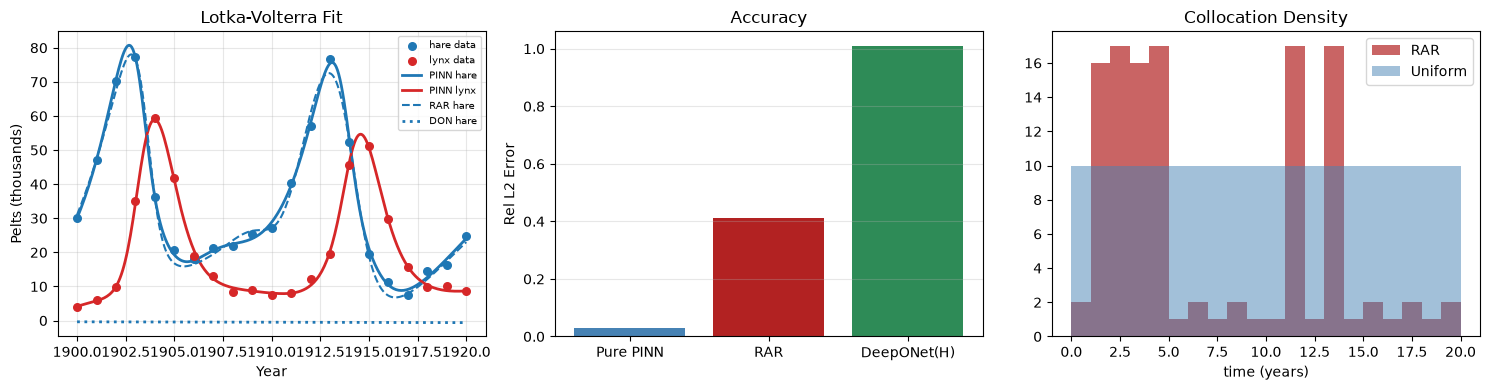

In [8]:

print("\n"+"="*55+"\nMETHOD COMPARISON — Lotka-Volterra\n"+"="*55)
print(f"{'Method':<25}{'Rel L2':>9}{'Time(s)':>9}{'#Pts':>7}")
print("-"*55)
print(f"{'Pure PINN (warm-start)':<25}{err_pinn:>9.4f}{time_pinn:>9.0f}{200:>7}")
print(f"{'RAR':<25}{err_rar:>9.4f}{time_rar:>9.0f}{t_rar_lv.shape[0]:>7}")
print(f"{'DeepONet (hare)':<25}{err_don:>9.4f}{time_don:>9.0f}{'N/A':>7}")
print("="*55)
fig,axes=plt.subplots(1,3,figsize=(15,4))
axes[0].scatter(year,hare,c='C0',s=30,zorder=5,label='hare data'); axes[0].scatter(year,lynx,c='C3',s=30,zorder=5,label='lynx data')
axes[0].plot(tg_lv,pr_lv[:,0],'C0-',lw=2,label='PINN hare'); axes[0].plot(tg_lv,pr_lv[:,1],'C3-',lw=2,label='PINN lynx')
axes[0].plot(tg_lv,pr_rar_lv[:,0],'C0--',lw=1.5,label='RAR hare'); axes[0].plot(tg_don_lv+1900,h_don,'C0:',lw=2,label='DON hare')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Pelts (thousands)'); axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3); axes[0].set_title('Lotka-Volterra Fit')
axes[1].bar(['Pure PINN','RAR','DeepONet(H)'],[err_pinn,err_rar,err_don],color=['steelblue','firebrick','seagreen'])
axes[1].set_ylabel('Rel L2 Error'); axes[1].set_title('Accuracy'); axes[1].grid(axis='y',alpha=0.3)
pt_r=t_rar_lv.detach().cpu().numpy().ravel()*T
axes[2].hist(pt_r,bins=20,color='firebrick',alpha=0.7,label='RAR'); axes[2].hist(np.linspace(0,T,200),bins=20,color='steelblue',alpha=0.5,label='Uniform')
axes[2].set_xlabel('time (years)'); axes[2].set_title('Collocation Density'); axes[2].legend()
plt.tight_layout(); plt.savefig('comparison_lv.png',dpi=120,bbox_inches='tight'); plt.show()
